Rats in dataset : 90
Features        : mean_feed_intake, mean_weight_gain, initial_bw, TDS_numeric, gender
Target          : final_body_weight

Target summary:
count     90.00
mean     259.47
std       73.15
min      137.00
25%      207.50
50%      256.50
75%      319.25
max      384.00
Name: target, dtype: float64

Train: 72 rats | Test: 18 rats

MODEL EVALUATION (Test Set — 20% held out)
            Model       R²   MAE (g)  RMSE (g)
Linear Regression 0.903683 14.908308 20.315781
    Random Forest 0.951914 11.449167 14.354627

5-Fold CV R²:
  Linear Regression : 0.9629 ± 0.0154
  Random Forest     : 0.9509 ± 0.0124

───────────────────────────────────────────────────────
LINEAR REGRESSION COEFFICIENTS
───────────────────────────────────────────────────────
  mean_feed_intake        β = +3.8313
  mean_weight_gain        β = +6.7104
  initial_bw              β = +1.0272
  TDS_numeric             β = -0.0251
  gender_enc              β = -4.2281
  Intercept               β = -28.4223

─

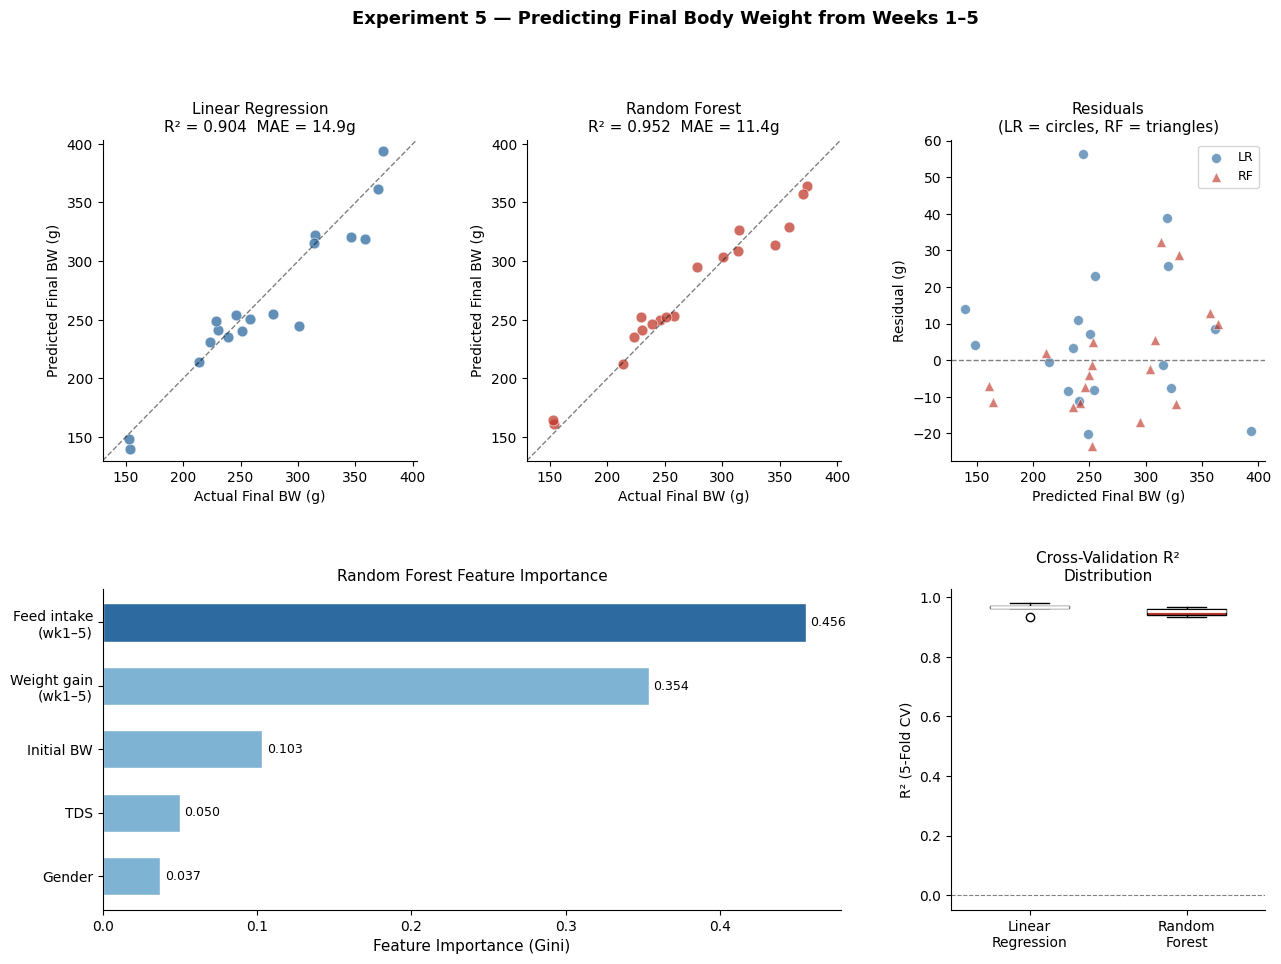

In [1]:
"""
Experiment 5 — ML Prediction of Final Body Weight
===================================================
Features from weeks 1–5 per rat:
  - mean_feed_intake     (mean of weekly_feed_intake, weeks 1–5)
  - mean_weight_gain     (mean of weekly_weight_gain, weeks 1–5)
  - TDS_numeric
  - gender (encoded)
Target:
  - final_body_weight (same value for all weeks of a rat → take first)

Models: Linear Regression, Random Forest
Eval  : 80/20 train/test split, R², MAE, RMSE
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0.  LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv("data/processed_rat_data.csv")   # <── change path

TDS_MAP = {
    "Group 1 (RO water with < 20 TDS)":                                                             20,
    "Group 7 (RO water <20 with alternate day fasting (feed withdrawal))":                          20,
    "Group 2 (RO water with 50-75 TDS)":                                                            62.5,
    "Group 3 (RO water with 125 - 150 TDS)":                                                        137.5,
    "Group 11 (RO Water 125 - 150 TDS with alternate day fasting)":                                 137.5,
    "Group 4 (Telugu Ganga water supplied to Tirupati)":                                            192,
    "Group 5 (Kalyani Dam water supplied to Tirupati)":                                             306,
    "Group 8 (Kalyani Dam water supplied to Tirupati with alternate day fasting (feed withdrawal))": 306,
    "Group 9 (water prepared as per BIS)":                                                          500,
    "Group 6 (Ground water Collected for Prakash nagar cology, Tirupati)":                          np.nan,
    "Group 10 (Ground water collected form prakshnagar colony with Alternate day fasting":           np.nan,
}

df["TDS_numeric"] = df["water_group"].map(TDS_MAP)
df["gender_enc"]  = LabelEncoder().fit_transform(df["gender"])  # female=0, male=1

# ─────────────────────────────────────────────
# 1.  BUILD RAT-LEVEL DATASET FROM WEEKS 1–5
# ─────────────────────────────────────────────
early = df[df["week"].between(1, 5)].copy()

rat_features = (
    early.groupby("unique_rat_id")
    .agg(
        mean_feed_intake  = ("weekly_feed_intake",  "mean"),
        mean_weight_gain  = ("weekly_weight_gain",  "mean"),
        initial_bw        = ("initial_body_weight", "first"),
        TDS_numeric       = ("TDS_numeric",          "first"),
        gender_enc        = ("gender_enc",            "first"),
    )
    .reset_index()
)

# Final body weight — same across all weeks per rat, take from week 15
final_bw = (
    df[df["week"] == 15]
    .groupby("unique_rat_id")["final_body_weight"]
    .first()
    .reset_index()
    .rename(columns={"final_body_weight": "target"})
)

rat_df = rat_features.merge(final_bw, on="unique_rat_id")

# Drop Prakash Nagar rats (NaN TDS) — optional, keeps dataset larger
rat_df_full  = rat_df.copy()                                 # includes Prakash Nagar
rat_df_notds = rat_df.dropna(subset=["TDS_numeric"]).copy()  # excludes Prakash Nagar

# Use full dataset (TDS will be NaN for Prakash Nagar → fill with median for RF,
# or use separate dataset — we'll use the complete TDS dataset for clean results)
rat_df = rat_df_notds.reset_index(drop=True)

print(f"Rats in dataset : {len(rat_df)}")
print(f"Features        : mean_feed_intake, mean_weight_gain, initial_bw, TDS_numeric, gender")
print(f"Target          : final_body_weight")
print(f"\nTarget summary:")
print(rat_df["target"].describe().round(2))

# ─────────────────────────────────────────────
# 2.  TRAIN / TEST SPLIT  (80/20, stratified by gender)
# ─────────────────────────────────────────────
FEATURES = ["mean_feed_intake", "mean_weight_gain", "initial_bw",
            "TDS_numeric", "gender_enc"]

X = rat_df[FEATURES].values
y = rat_df["target"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, rat_df.index.values,
    test_size   = 0.2,
    random_state= 42,
    stratify    = rat_df["gender_enc"],   # keep gender balanced in both splits
)

print(f"\nTrain: {len(X_train)} rats | Test: {len(X_test)} rats")

# ─────────────────────────────────────────────
# 3.  FIT MODELS
# ─────────────────────────────────────────────
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, random_state=42, max_features="sqrt")

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)

# ─────────────────────────────────────────────
# 4.  EVALUATE
# ─────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Model": name, "R²": r2, "MAE (g)": mae, "RMSE (g)": rmse}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, pred_lr),
    evaluate("Random Forest",     y_test, pred_rf),
])

print("\n" + "=" * 55)
print("MODEL EVALUATION (Test Set — 20% held out)")
print("=" * 55)
print(results.to_string(index=False))

# Cross-validation for more robust estimate
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_lr = cross_val_score(lr, X, y, cv=cv, scoring="r2")
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring="r2")

print(f"\n5-Fold CV R²:")
print(f"  Linear Regression : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"  Random Forest     : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

# Linear regression coefficients
print("\n" + "─" * 55)
print("LINEAR REGRESSION COEFFICIENTS")
print("─" * 55)
for feat, coef in zip(FEATURES, lr.coef_):
    print(f"  {feat:<22}  β = {coef:+.4f}")
print(f"  {'Intercept':<22}  β = {lr.intercept_:+.4f}")

# Random Forest feature importance
print("\n" + "─" * 55)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("─" * 55)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, imp in importances.items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<22}  {imp:.4f}  {bar}")

# ─────────────────────────────────────────────
# 5.  PLOT
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Shared axis limits for predicted vs actual plots
all_vals = np.concatenate([y_test, pred_lr, pred_rf])
lim = (all_vals.min() - 10, all_vals.max() + 10)

# ── Top Left: LR predicted vs actual ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, pred_lr, color="#2d6a9f", alpha=0.75, s=60, edgecolors="white", linewidth=0.5)
ax1.plot(lim, lim, "k--", linewidth=1, alpha=0.5, label="Perfect prediction")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("Actual Final BW (g)"); ax1.set_ylabel("Predicted Final BW (g)")
ax1.set_title(f"Linear Regression\nR² = {results.loc[0,'R²']:.3f}  MAE = {results.loc[0,'MAE (g)']:.1f}g", fontsize=11)
ax1.spines[["top","right"]].set_visible(False)

# ── Top Middle: RF predicted vs actual ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, pred_rf, color="#c0392b", alpha=0.75, s=60, edgecolors="white", linewidth=0.5)
ax2.plot(lim, lim, "k--", linewidth=1, alpha=0.5)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("Actual Final BW (g)"); ax2.set_ylabel("Predicted Final BW (g)")
ax2.set_title(f"Random Forest\nR² = {results.loc[1,'R²']:.3f}  MAE = {results.loc[1,'MAE (g)']:.1f}g", fontsize=11)
ax2.spines[["top","right"]].set_visible(False)

# ── Top Right: Residuals comparison ──
ax3 = fig.add_subplot(gs[0, 2])
resid_lr = y_test - pred_lr
resid_rf = y_test - pred_rf
ax3.axhline(0, color="gray", linewidth=1, linestyle="--")
ax3.scatter(pred_lr, resid_lr, color="#2d6a9f", alpha=0.65, s=50, label="LR", edgecolors="white", linewidth=0.5)
ax3.scatter(pred_rf, resid_rf, color="#c0392b", alpha=0.65, s=50, label="RF", marker="^", edgecolors="white", linewidth=0.5)
ax3.set_xlabel("Predicted Final BW (g)"); ax3.set_ylabel("Residual (g)")
ax3.set_title("Residuals\n(LR = circles, RF = triangles)", fontsize=11)
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)

# ── Bottom Left: Feature importance (RF) ──
ax4 = fig.add_subplot(gs[1, 0:2])
feat_labels = ["Feed intake\n(wk1–5)", "Weight gain\n(wk1–5)", "Initial BW", "TDS", "Gender"]
colors_imp  = ["#2d6a9f" if i == importances.values.argmax() else "#7fb3d3" for i in range(len(FEATURES))]
bars = ax4.barh(feat_labels[::-1], importances.values[::-1],
                color=colors_imp[::-1], edgecolor="white", height=0.6)
ax4.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax4.set_title("Random Forest Feature Importance", fontsize=11)
for bar, val in zip(bars, importances.values[::-1]):
    ax4.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
ax4.spines[["top","right"]].set_visible(False)

# ── Bottom Right: CV R² comparison ──
ax5 = fig.add_subplot(gs[1, 2])
box_data = [cv_lr, cv_rf]
bp = ax5.boxplot(box_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor("#2d6a9f")
bp["boxes"][1].set_facecolor("#c0392b")
ax5.set_xticks([1, 2])
ax5.set_xticklabels(["Linear\nRegression", "Random\nForest"])
ax5.set_ylabel("R² (5-Fold CV)")
ax5.set_title("Cross-Validation R²\nDistribution", fontsize=11)
ax5.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax5.spines[["top","right"]].set_visible(False)

plt.suptitle("Experiment 5 — Predicting Final Body Weight from Weeks 1–5",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig("outputs/ML_models/ml_prediction.png", dpi=150, bbox_inches="tight")
print("\nPlot saved → experiment5_ml_prediction.png")
plt.show()